In [43]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import pickle
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, LSTM, GlobalAveragePooling1D, Dense, ReLU, Reshape, LayerNormalization
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

In [45]:
train = pickle.load(open('ECG5000/ECG5000_train.pickle', 'rb'), encoding = 'latin1')
test = pickle.load(open('ECG5000/ECG5000_validation.pickle', 'rb'), encoding = 'latin1')
data = np.concatenate((train, test), axis=0)


# Split features and labels
X = data[:, 1:]
y = data[:, 0]  # Labels

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Reshape to (samples, timesteps, 1)
X = X.reshape(X.shape[0], X.shape[1], 1)

# Encode labels to 0-based
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = to_categorical(y_encoded)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42)

In [47]:
def build_fcn_lstm_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    # Fully convolutional block
    x = Conv1D(128, kernel_size=8, padding='same')(inputs)
    x = ReLU()(x)
    
    x = Conv1D(256, kernel_size=5, padding='same')(x)
    x = ReLU()(x)
    
    x = Conv1D(128, kernel_size=3, padding='same')(x)
    x = ReLU()(x)

    x = LSTM(64, return_sequences=False)(x)  # Now correctly 2D
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model

model = build_fcn_lstm_model((140, 1), num_classes=5)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 140, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 140, 128)       │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 140, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 140, 256)       │       164,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 140, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 140, 128)       │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 140, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 313,413 (1.20 MB)

 Trainable params: 313,413 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
history = model.fit(X_train, y_train, epochs=30, batch_size=64, validation_split=0.1)

Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 229ms/step - accuracy: 0.9512 - loss: 0.1566 - val_accuracy: 0.9500 - val_loss: 0.1799
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 210ms/step - accuracy: 0.9579 - loss: 0.1459 - val_accuracy: 0.9438 - val_loss: 0.1950
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 217ms/step - accuracy: 0.9484 - loss: 0.1681 - val_accuracy: 0.9312 - val_loss: 0.2225
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 233ms/step - accuracy: 0.9657 - loss: 0.1212 - val_accuracy: 0.9312 - val_loss: 0.2482
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 192ms/step - accuracy: 0.9538 - loss: 0.1552 - val_accuracy: 0.9438 - val_loss: 0.1989
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 214ms/step - accuracy: 0.9589 - loss: 0.1276 - val_accuracy: 0.9563 - val_loss: 0.1979
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 243ms/step - accuracy: 0.9659 - loss: 0.1259 - val_accuracy: 0.9375 - val_loss: 0.2407
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 205ms/step - accuracy: 0.9615 - loss: 0.1352 - val_accuracy: 0.

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.9193 - loss: 0.2721
Test Accuracy: 0.8975


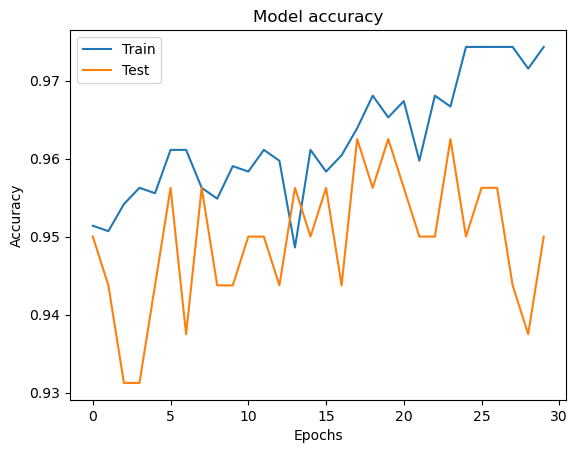

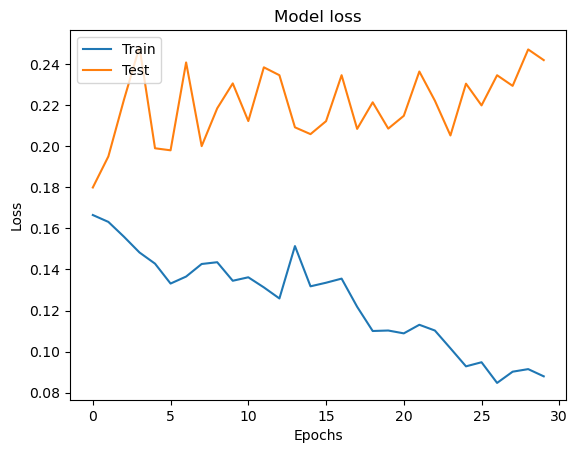

In [57]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.4f}")


plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()